MB_MW: miền bắc

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [2]:
# Load CSV
df = pd.read_csv("./dataset/VN_Energy.csv")

# Ensure datetime
df["date"] = pd.to_datetime(df["date"]) 
df = df.set_index("date")

In [3]:
df.columns

Index(['MB_MW', 'MT_MW', 'MN_MW', 'HT_MW'], dtype='object')

In [4]:
df.shape

(38688, 4)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 38688 entries, 2021-01-01 00:00:00 to 2025-05-31 23:00:00
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   MB_MW   38688 non-null  float64
 1   MT_MW   38688 non-null  float64
 2   MN_MW   38688 non-null  float64
 3   HT_MW   38688 non-null  float64
dtypes: float64(4)
memory usage: 1.5 MB


In [6]:
df.describe()

,MB_MW,MT_MW,MN_MW,HT_MW
count,38688.000000,38688.000000,38688.000000,38688.000000
mean,14955.712107,3056.399949,14242.815136,32254.927229
std,2968.918570,688.784290,2719.502089,5805.464747
min,5459.400000,648.500000,5116.027000,12897.400000
25%,12881.650000,2554.850000,12280.650000,28188.875000
50%,14903.700000,3028.200000,14310.975000,32334.100000
75%,16948.625000,3537.000000,16244.075000,36406.800000
max,25774.700000,5890.600000,22584.300000,50032.200000


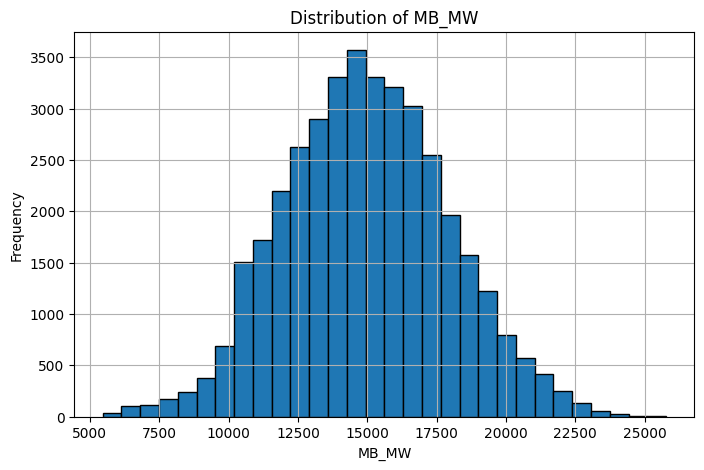

In [7]:
col = 'MB_MW'
# Distribution (histogram + KDE)
plt.figure(figsize=(8,5))
df[col].hist(bins=30, edgecolor="black")   # histogram
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")
plt.show()

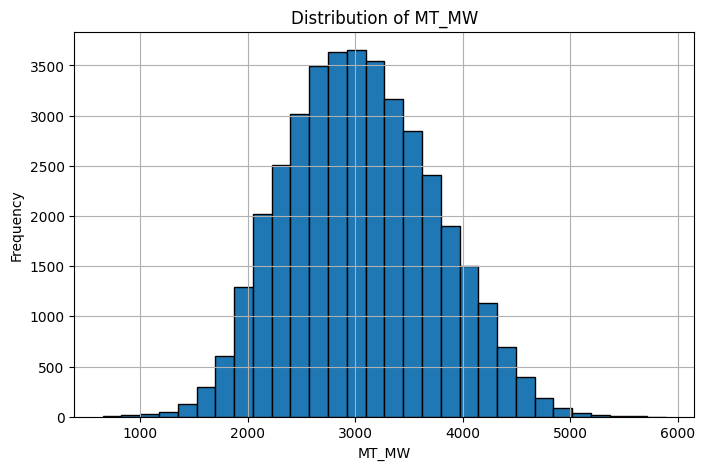

In [8]:
col = 'MT_MW'
# Distribution (histogram + KDE)
plt.figure(figsize=(8,5))
df[col].hist(bins=30, edgecolor="black")   # histogram
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")
plt.show()

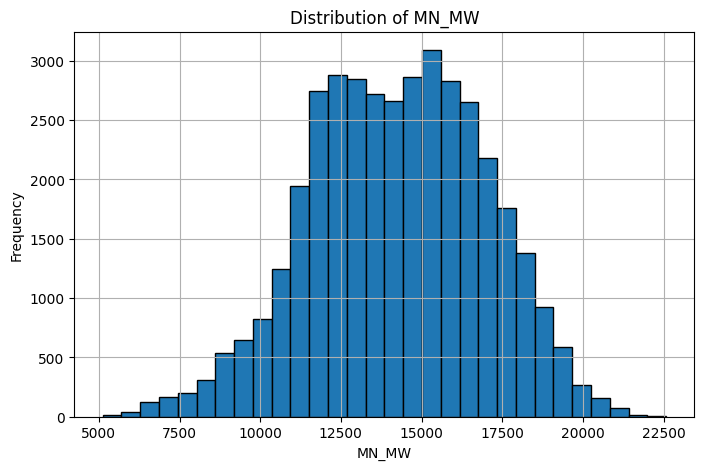

In [9]:
col = 'MN_MW'
# Distribution (histogram + KDE)
plt.figure(figsize=(8,5))
df[col].hist(bins=30, edgecolor="black")   # histogram
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")
plt.show()

C:\Users\Hi\AppData\Local\Temp\ipykernel_127728\1286020358.py:2: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df_yearly_sum = df.resample("Y").sum()


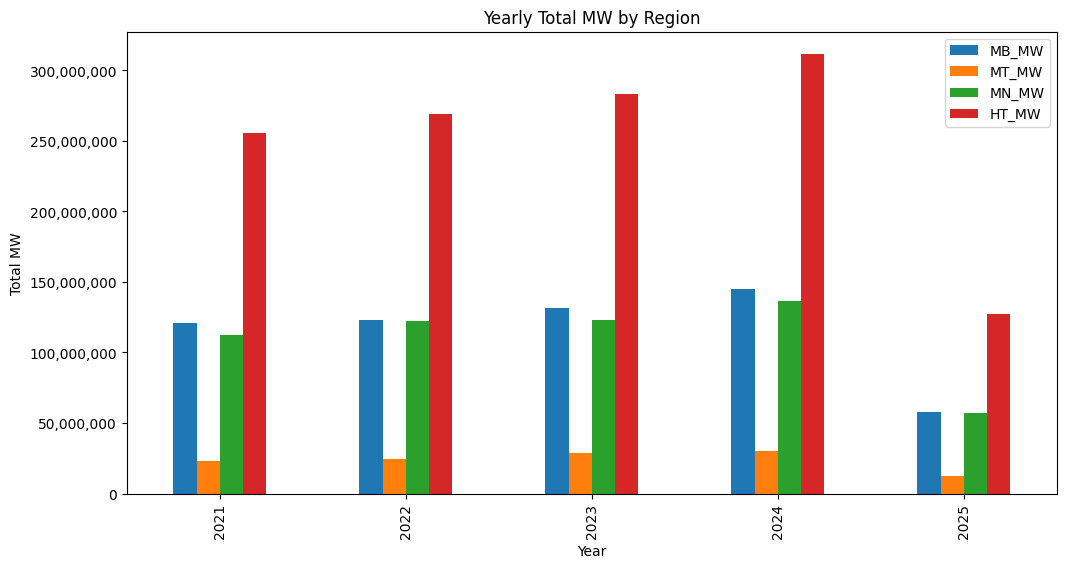

In [10]:
# Group by year and sum
df_yearly_sum = df.resample("Y").sum()
df_yearly_sum.index = df_yearly_sum.index.year

ax = df_yearly_sum.plot(kind="bar", figsize=(12,6))
plt.title("Yearly Total MW by Region")
plt.xlabel("Year")
plt.ylabel("Total MW")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

plt.show()


C:\Users\Hi\AppData\Local\Temp\ipykernel_127728\4107936705.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df_yearly_avg = df.resample("Y").mean()


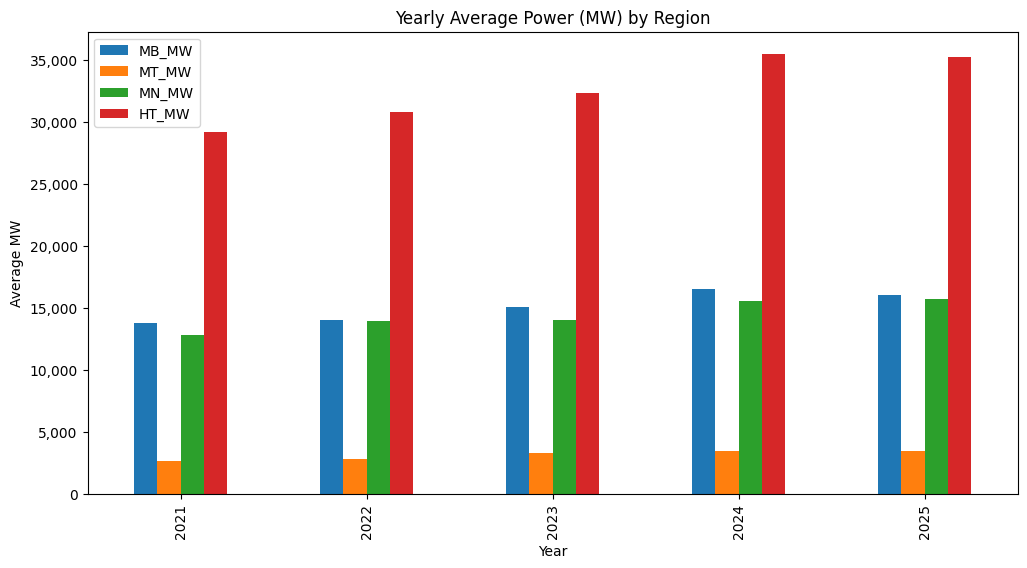

In [11]:
df_yearly_avg = df.resample("Y").mean()
df_yearly_avg.index = df_yearly_avg.index.year

ax = df_yearly_avg.plot(kind="bar", figsize=(12,6))
ax.set_title("Yearly Average Power (MW) by Region")
ax.set_xlabel("Year")
ax.set_ylabel("Average MW")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))  # no scientific notation
plt.show()


C:\Users\Hi\AppData\Local\Temp\ipykernel_127728\1702126506.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.resample("M").sum()


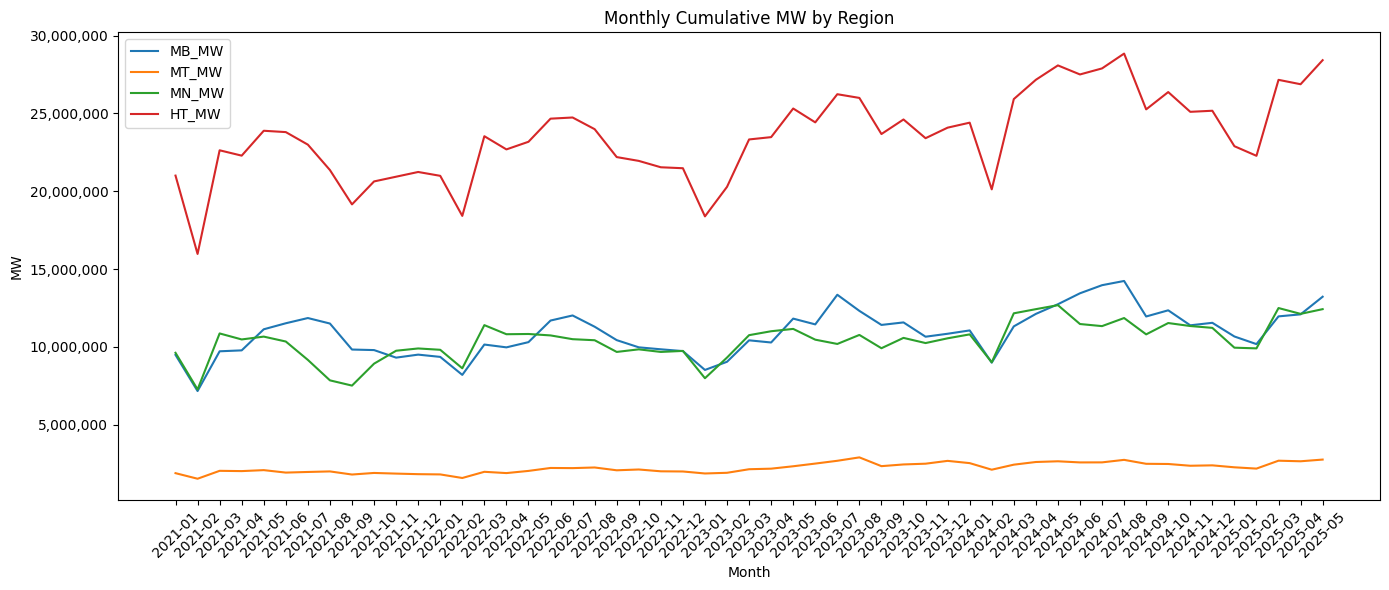

In [12]:
# Monthly cumulative (summing each month)
df_monthly = df.resample("M").sum()
df_monthly.index = df_monthly.index.to_period("M")

# Plot as line chart
fig, ax = plt.subplots(figsize=(14,6))
for col in df_monthly.columns:
    ax.plot(df_monthly.index.astype(str), df_monthly[col], label=col)

ax.set_title("Monthly Cumulative MW by Region")
ax.set_xlabel("Month")
ax.set_ylabel("MW")

# Format y-axis without scientific notation, add thousands separator
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


C:\Users\Hi\AppData\Local\Temp\ipykernel_127728\3306824259.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.resample("M").mean()


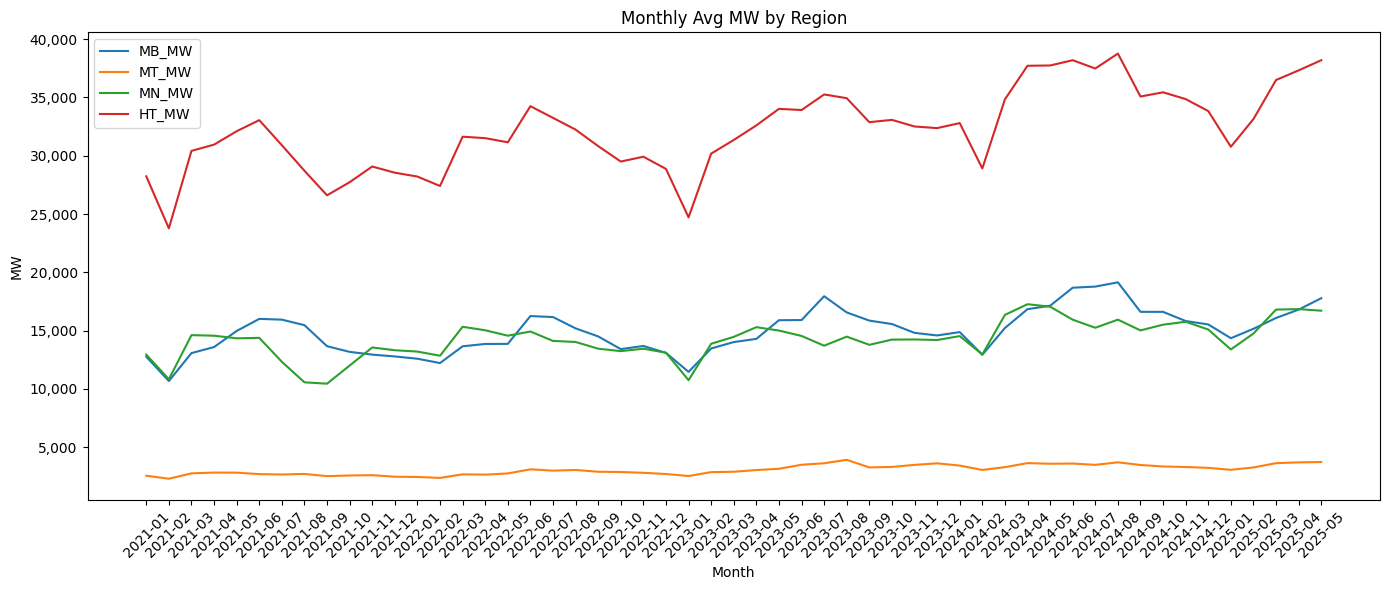

In [13]:
# Monthly cumulative (summing each month)
df_monthly = df.resample("M").mean()
df_monthly.index = df_monthly.index.to_period("M")

# Plot as line chart
fig, ax = plt.subplots(figsize=(14,6))
for col in df_monthly.columns:
    ax.plot(df_monthly.index.astype(str), df_monthly[col], label=col)

ax.set_title("Monthly Avg MW by Region")
ax.set_xlabel("Month")
ax.set_ylabel("MW")

# Format y-axis without scientific notation, add thousands separator
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()